# WP1 Tutorial: Information Content for Clock Data

**Time to run:** ~2 minutes on a laptop.  
**Audience:** Graduate student or postdoc in physics who knows Python and basic statistics but has never heard of IC.  
**What this covers:** The core WP1 arc — defining IC, calibrating it under null conditions, understanding its limitations, and positioning it against familiar figures of merit.  
**What this does not cover:** The full calibration runs (300 realisations x 10 models). For those, see the [logbook entries](../logbook/) and the [data archive](../data/).  

---

## The problem

Modern timekeeping relies on networks of clocks that continuously compare their readings and agree on a shared timescale. The best optical clocks now reach fractional uncertainties below 10^{-18} — sensitive enough to detect height differences of a few centimetres through gravitational time dilation.

At this precision, clocks disagree. The standard response is robust averaging: suppress outliers so the consensus remains stable. This works when deviations are random noise.

But what if some disagreements carry information? A clock drifting systematically might indicate an environmental change. By suppressing it, we lose that signal. This project asks whether distinguishing *structured* anomalies (persistent drifts, growing variance) from *unstructured* ones (random outliers) — and treating them differently — improves consensus. The first step is to define and calibrate a measure of how surprising each reading is. That measure is **information content (IC)**.

For the non-technical version, see the [outreach document](../docs/outreach.md). For the full technical record, see the [WP1 summary](../logbook/wp1-summary.md).

## 1. Setup

The codebase is small: three implemented modules in `src/`. We'll use all three.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as norm_dist

from ic import compute_ic, compute_aipp, aipp_gaussian_limit, perturb_sigmas
from noise import generate_pareto_symmetric, generate_flicker, generate_random_walk, generate_ar1
from temporal import compute_temporal_structure, calibrate_delta_min

# Reproducibility
rng = np.random.default_rng(2026)

# Plotting defaults
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print(f"Modules loaded. NumPy {np.__version__}.")

Modules loaded. NumPy 1.23.5.


## 2. What is IC?

A single clock produces N readings over time, each with a declared measurement uncertainty. IC asks: **how consistent is each reading with the clock's own track record?**

The idea is simple. We build a background density from all N readings — a Gaussian mixture where each reading contributes one component — and then ask how much probability mass that density assigns to the neighbourhood of each individual reading. Readings that sit in low-density regions of the mixture get high IC.

Formally, for N readings $x_1, \ldots, x_N$ with uncertainties $\sigma_1, \ldots, \sigma_N$:

$$P(y) = \frac{1}{N} \sum_{i=1}^{N} \mathcal{N}(y;\, x_i,\, \sigma_i)$$

The interval probability for reading $k$ is:

$$p_k = \int_{x_k - \sigma_k}^{x_k + \sigma_k} P(y)\, dy$$

And the information content is:

$$I_k = -\log_2(p_k) \quad [\text{bits}]$$

Let's see this in action. We'll generate 50 Gaussian readings, build P(y), and show how a tail reading gets high IC.

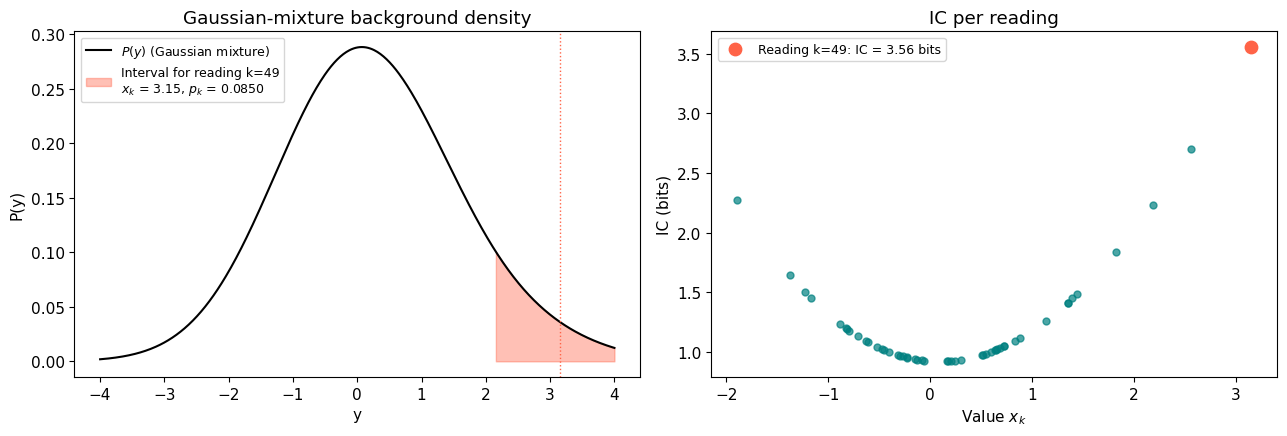

Reading k=49: value = 3.15, IC = 3.56 bits
Points near zero have low IC; points in the tails have high IC.


In [2]:
# Generate 50 Gaussian readings with sigma = 1
N = 50
values = rng.normal(0, 1, N)
sigmas = np.ones(N)

# Build P(y) explicitly for plotting
y_grid = np.linspace(-4, 4, 500)
P_y = np.zeros_like(y_grid)
for i in range(N):
    P_y += norm_dist.pdf(y_grid, values[i], sigmas[i])
P_y /= N

# Pick one point to illustrate: the one furthest from zero
k = np.argmax(np.abs(values))
x_k, sigma_k = values[k], sigmas[k]

# Compute IC for all points
ic = compute_ic(values, sigmas)

# --- Figure: P(y) with the interval for point k highlighted ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: the mixture density and the interval
ax1.plot(y_grid, P_y, 'k-', linewidth=1.5, label='$P(y)$ (Gaussian mixture)')
ax1.fill_between(y_grid, P_y,
                 where=(y_grid >= x_k - sigma_k) & (y_grid <= x_k + sigma_k),
                 alpha=0.4, color='tomato',
                 label=f'Interval for reading k={k}\n'
                       f'$x_k$ = {x_k:.2f}, $p_k$ = {2**(-ic[k]):.4f}')
ax1.axvline(x_k, color='tomato', linestyle=':', linewidth=1)
ax1.set_xlabel('y')
ax1.set_ylabel('P(y)')
ax1.set_title('Gaussian-mixture background density')
ax1.legend(fontsize=9)

# Right: IC vs value
ax2.scatter(values, ic, c='teal', s=25, alpha=0.7)
ax2.scatter(values[k], ic[k], c='tomato', s=80, zorder=5,
            label=f'Reading k={k}: IC = {ic[k]:.2f} bits')
ax2.set_xlabel('Value $x_k$')
ax2.set_ylabel('IC (bits)')
ax2.set_title('IC per reading')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Reading k={k}: value = {x_k:.2f}, IC = {ic[k]:.2f} bits")
print(f"Points near zero have low IC; points in the tails have high IC.")

## 3. The outlier demo

A practical sanity check: if we inject two obvious outliers into otherwise well-behaved data, IC should flag them. This is fig03 from logbook Entry 001, rebuilt live.

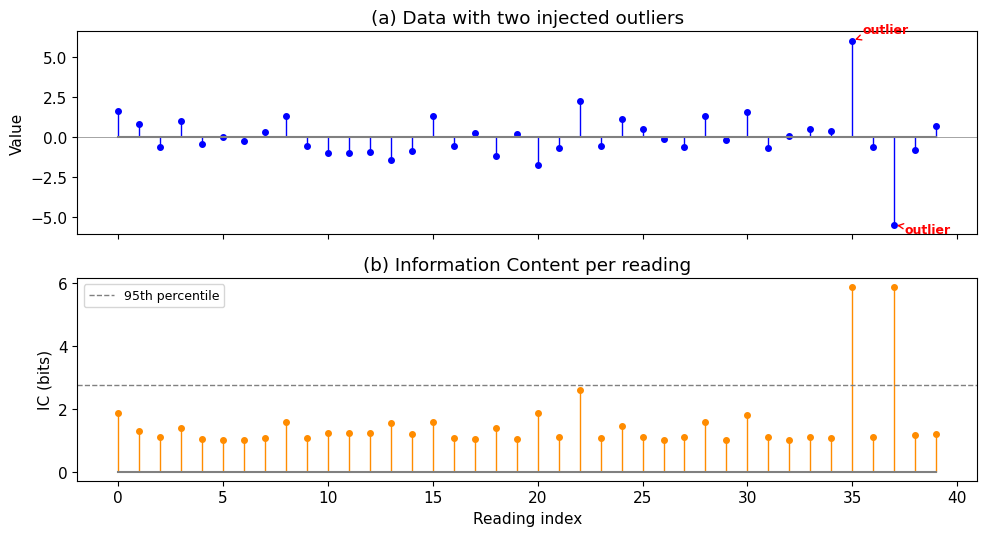

Outlier at index 35 (value=6.0):  IC = 5.86 bits
Outlier at index 37 (value=-5.5): IC = 5.86 bits
Median IC of normal points:       1.11 bits


In [3]:
# 40 Gaussian points with two injected outliers
n = 40
values_demo = rng.normal(0, 1, n)
values_demo[35] = 6.0
values_demo[37] = -5.5
sigmas_demo = np.ones(n)

ic_demo = compute_ic(values_demo, sigmas_demo)
threshold_95 = np.percentile(ic_demo, 95)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

# Data
markerline, stemlines, baseline = ax1.stem(range(n), values_demo, linefmt='b-',
                                            markerfmt='bo', basefmt='gray')
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=4)
for idx in [35, 37]:
    ax1.annotate('outlier', xy=(idx, values_demo[idx]),
                 xytext=(idx + 0.5, values_demo[idx] + (0.5 if values_demo[idx] > 0 else -0.5)),
                 fontsize=9, color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1))
ax1.set_ylabel('Value')
ax1.set_title('(a) Data with two injected outliers')
ax1.axhline(0, color='gray', linewidth=0.5)

# IC
markerline, stemlines, baseline = ax2.stem(range(n), ic_demo, linefmt='-',
                                            markerfmt='o', basefmt='gray')
plt.setp(stemlines, color='darkorange', linewidth=1)
plt.setp(markerline, color='darkorange', markersize=4)
ax2.axhline(threshold_95, color='gray', linestyle='--', linewidth=1, label='95th percentile')
ax2.set_xlabel('Reading index')
ax2.set_ylabel('IC (bits)')
ax2.set_title('(b) Information Content per reading')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Outlier at index 35 (value=6.0):  IC = {ic_demo[35]:.2f} bits")
print(f"Outlier at index 37 (value=-5.5): IC = {ic_demo[37]:.2f} bits")
print(f"Median IC of normal points:       {np.median(ic_demo[np.array([i for i in range(n) if i not in [35,37]])]):.2f} bits")

## 4. How does AIPP behave under the null?

AIPP (average information per point) is the ensemble-level summary: the mean IC across all N readings. Under the Gaussian null, AIPP converges to a theoretical limit as N grows.

**The key insight:** as N increases, the Gaussian mixture P(y) converges to a broader distribution than any single component — specifically, to $\mathcal{N}(0, \sqrt{2})$ when $\sigma_\text{data} = \sigma_\text{declared} = 1$. This is the convolution of the data distribution with the Gaussian kernel. The broader background means each reading's interval captures *less* probability mass, giving higher IC.

An earlier version of the project proposal incorrectly claimed AIPP $\to$ 0.55 bit, based on considering only the self-contribution of each reading. The correct value is **1.25 bit**. See logbook [Entry 001](../logbook/001_2026-03-31_ic-implementation-and-aipp-correction.md) for the full derivation.

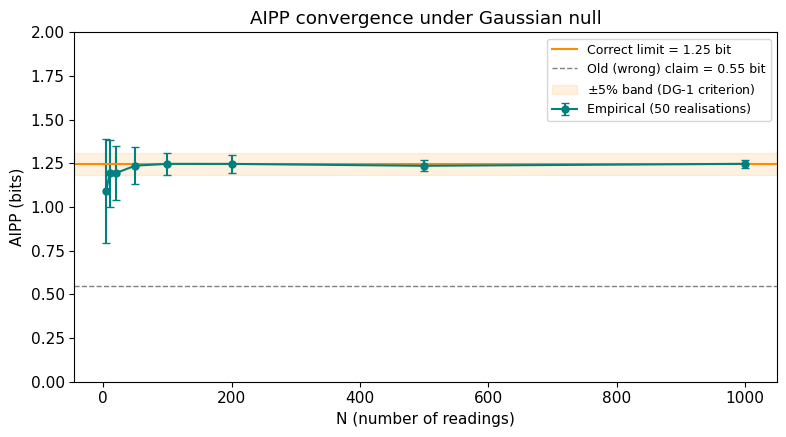

Theoretical limit: 1.2482 bit
At N=100: AIPP = 1.247 +/- 0.064
At N=1000: AIPP = 1.247 +/- 0.023


In [4]:
# AIPP convergence: compute at increasing N (50 realisations each, for speed)
Ns = [5, 10, 20, 50, 100, 200, 500, 1000]
n_real = 50
rng_conv = np.random.default_rng(2026)

means, stds = [], []
for n in Ns:
    aipps = [compute_aipp(compute_ic(rng_conv.normal(0, 1, n), np.ones(n)))
             for _ in range(n_real)]
    means.append(np.mean(aipps))
    stds.append(np.std(aipps))

means, stds = np.array(means), np.array(stds)
limit = aipp_gaussian_limit()  # theoretical ~1.25 bit

from scipy.special import erf
old_claim = -np.log2(erf(1.0 / np.sqrt(2.0)))  # the incorrect 0.55 bit

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(Ns, means, yerr=stds, fmt='o-', color='teal', markersize=5,
            capsize=3, label=f'Empirical ({n_real} realisations)')
ax.axhline(limit, color='darkorange', linewidth=1.5,
           label=f'Correct limit = {limit:.2f} bit')
ax.axhline(old_claim, color='gray', linewidth=1, linestyle='--',
           label=f'Old (wrong) claim = {old_claim:.2f} bit')
ax.axhspan(limit * 0.95, limit * 1.05, color='darkorange', alpha=0.12,
           label='$\pm$5% band (DG-1 criterion)')
ax.set_xlabel('N (number of readings)')
ax.set_ylabel('AIPP (bits)')
ax.set_title('AIPP convergence under Gaussian null')
ax.legend(fontsize=9)
ax.set_ylim(0, 2.0)
plt.tight_layout()
plt.show()

print(f"Theoretical limit: {limit:.4f} bit")
print(f"At N=100: AIPP = {means[Ns.index(100)]:.3f} +/- {stds[Ns.index(100)]:.3f}")
print(f"At N=1000: AIPP = {means[Ns.index(1000)]:.3f} +/- {stds[Ns.index(1000)]:.3f}")

## 5. Is IC robust across noise types?

A useful anomaly detector shouldn't require knowing the exact noise model. We test IC under four contrasting distributions: Gaussian (the baseline), Student-t with 3 degrees of freedom (heavy tails), AR(1) with $\rho = 0.9$ (strong temporal correlation), and random walk (non-stationary).

The DG-1 criterion requires that 95th-percentile thresholds remain within a factor of 1.5 across noise models. The full calibration (10 models, 300 realisations each) is in logbook [Entry 003](../logbook/003_2026-03-31_powerlaw-nulls-and-finite-n-bias.md). Here we run a quick version with 4 models and 50 realisations.

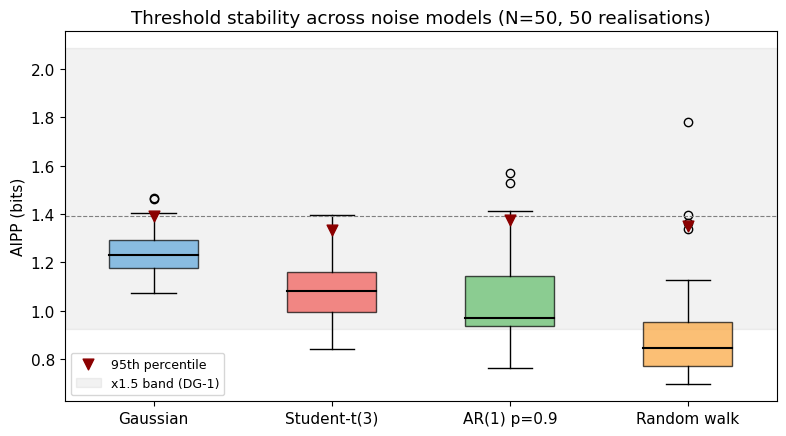

95th-percentile range: 1.333 to 1.390
Max pairwise ratio: 1.04x (DG-1 requires < 1.5x)


In [5]:
N_thr = 50
n_real_thr = 50
rng_thr = np.random.default_rng(2026)

models = {
    'Gaussian': lambda: (rng_thr.normal(0, 1, N_thr), np.ones(N_thr)),
    'Student-t(3)': lambda: (rng_thr.standard_t(3, N_thr), np.ones(N_thr) * np.sqrt(3)),
    'AR(1) p=0.9': lambda: (generate_ar1(N_thr, rho=0.9, rng=rng_thr), np.ones(N_thr)),
    'Random walk': lambda: (generate_random_walk(N_thr, rng=rng_thr),
                            np.maximum(np.sqrt(np.arange(1, N_thr + 1, dtype=float)), 1.0)),
}

results = {}
for name, gen in models.items():
    aipps = []
    for _ in range(n_real_thr):
        v, s = gen()
        aipps.append(compute_aipp(compute_ic(v, s)))
    results[name] = np.array(aipps)

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = list(results.keys())
data = [results[l] for l in labels]
colors = ['#5DA5DA', '#F15854', '#60BD68', '#FAA43A']
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

# Mark 95th percentiles
p95s = [np.percentile(d, 95) for d in data]
ax.scatter(range(1, len(p95s) + 1), p95s, marker='v', color='darkred',
           s=60, zorder=5, label='95th percentile')

gaussian_p95 = p95s[0]
ax.axhspan(gaussian_p95 / 1.5, gaussian_p95 * 1.5, color='gray', alpha=0.1,
           label=f'x1.5 band (DG-1)')
ax.axhline(gaussian_p95, color='gray', linestyle='--', linewidth=0.8)

ax.set_ylabel('AIPP (bits)')
ax.set_title(f'Threshold stability across noise models (N={N_thr}, {n_real_thr} realisations)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print the ratio
max_p95 = max(p95s)
min_p95 = min(p95s)
print(f"95th-percentile range: {min_p95:.3f} to {max_p95:.3f}")
print(f"Max pairwise ratio: {max_p95/min_p95:.2f}x (DG-1 requires < 1.5x)")

## 6. What happens when $\sigma$ is wrong?

IC depends on the declared uncertainty $\sigma_k$ — it sets both the width of each mixture component and the integration interval. What happens when $\sigma$ is systematically wrong?

We test three perturbation conditions against the unperturbed baseline:
- **Random $\pm$20%:** each $\sigma_k$ is independently perturbed by a random factor in $[-0.2, +0.2]$.
- **Systematic +20%:** all $\sigma_k$ are overestimated by 20%.
- **Systematic $-$20%:** all $\sigma_k$ are underestimated by 20%.

The pre-registered bound is 15% AIPP shift. See logbook [Entry 002](../logbook/002_2026-03-31_sigma-sensitivity-analysis.md) for the full analysis.

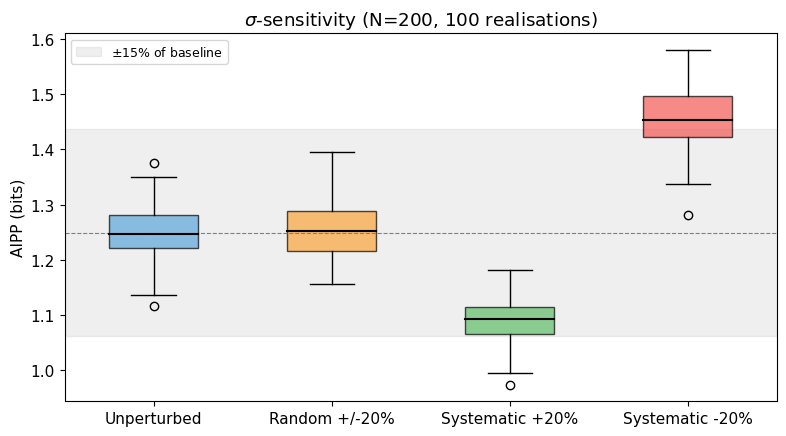

Condition               Mean AIPP    Shift
--------------------------------------------
Unperturbed                1.2492    +0.0%
Random +/-20%              1.2542    +0.4%
Systematic +20%            1.0869   -13.0%
Systematic -20%            1.4592   +16.8% <-- FAIL


In [6]:
N_sens = 200
n_real_sens = 100
rng_sens = np.random.default_rng(2026)

conditions = [
    ('Unperturbed', None),
    ('Random +/-20%', 'random'),
    ('Systematic +20%', 'systematic+'),
    ('Systematic -20%', 'systematic-'),
]

sens_results = {}
for label, mode in conditions:
    aipps = []
    for _ in range(n_real_sens):
        v = rng_sens.normal(0, 1, N_sens)
        s_true = np.ones(N_sens)
        s_used = s_true if mode is None else perturb_sigmas(s_true, mode=mode,
                                                             magnitude=0.2, rng=rng_sens)
        aipps.append(compute_aipp(compute_ic(v, s_used)))
    sens_results[label] = np.array(aipps)

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = list(sens_results.keys())
data = [sens_results[l] for l in labels]
colors = ['#5DA5DA', '#FAA43A', '#60BD68', '#F15854']
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

baseline = np.mean(sens_results['Unperturbed'])
ax.axhspan(baseline * 0.85, baseline * 1.15, color='gray', alpha=0.12,
           label='$\pm$15% of baseline')
ax.axhline(baseline, color='gray', linestyle='--', linewidth=0.8)

ax.set_ylabel('AIPP (bits)')
ax.set_title(f'$\\sigma$-sensitivity (N={N_sens}, {n_real_sens} realisations)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print shifts
print(f"{'Condition':<22} {'Mean AIPP':>10} {'Shift':>8}")
print("-" * 44)
for label in labels:
    m = np.mean(sens_results[label])
    shift = (m - baseline) / baseline * 100
    flag = " <-- FAIL" if abs(shift) > 15 else ""
    print(f"{label:<22} {m:10.4f} {shift:+7.1f}%{flag}")

The asymmetry is expected. Underestimating $\sigma$ narrows the integration interval $[x_k - \sigma_k,\, x_k + \sigma_k]$, capturing less probability mass from the mixture, so IC rises. This is the single identified failure in WP1: the systematic $-$20% case exceeds the pre-registered 15% bound. The mitigation for WP2 is worst-case threshold calibration — procedural, not intrinsic.

## 7. Two kinds of surprise

IC tells us *that* a reading is anomalous, but not *why*. A one-off noise spike and a persistent drift both produce high IC. To distinguish them, we need temporal-structure statistics computed over a trailing window:

- **Variance slope:** is the noise growing over time?
- **Lag-1 autocorrelation:** are successive readings correlated (the classic critical-slowing-down indicator)?

Each has a calibrated threshold $\delta_\text{min}$ from null distributions (see logbook [Entry 004](../logbook/004_2026-03-31_delta-min-calibration.md)):
- $\delta_\text{min}(\text{var slope}) = 0.2105$
- $\delta_\text{min}(\text{autocorr}) = 0.8703$

Let's compare a clean Gaussian series against a drifting one.

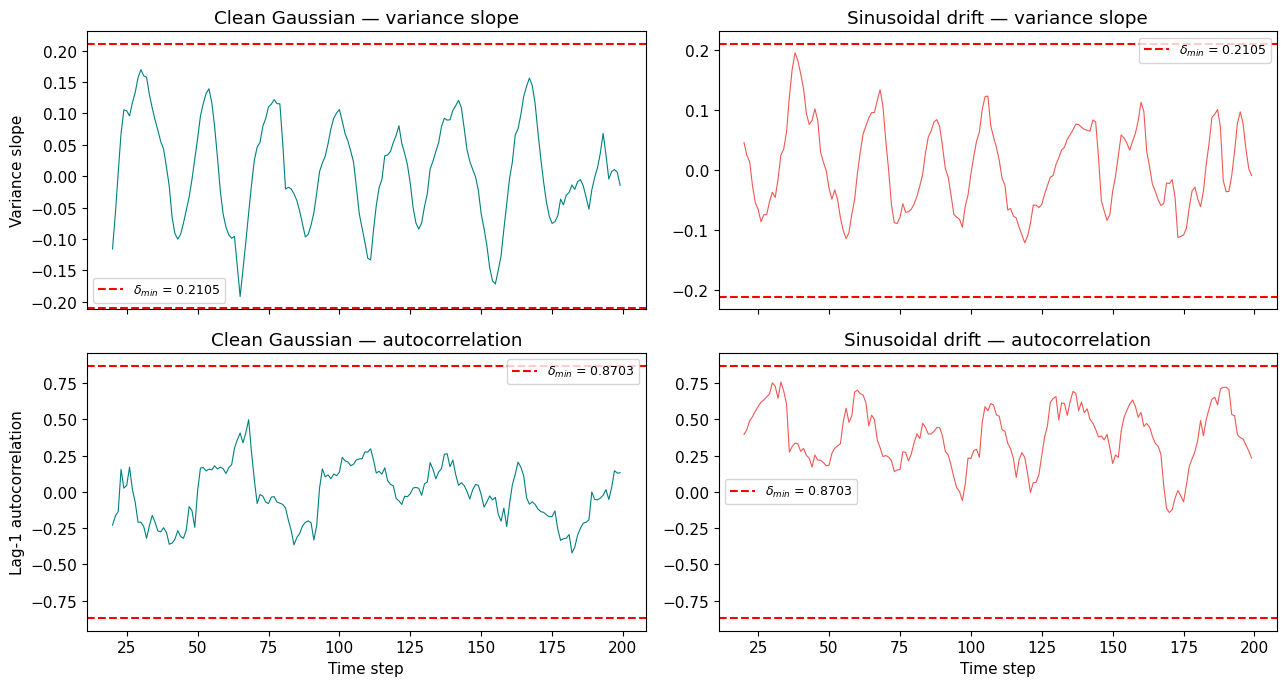

Clean:    max |var_slope| = 0.192  (threshold: 0.2105)
          max |autocorr|  = 0.497  (threshold: 0.8703)
Drifting: max |autocorr|  = 0.756  (threshold: 0.8703)

The drift exceeds delta_min. The clean series does not.


In [7]:
T = 200
W = 20
DELTA_VAR = 0.2105
DELTA_ACF = 0.8703
rng_ts = np.random.default_rng(2026)

# Clean Gaussian series
clean = rng_ts.normal(0, 1, T)

# Drifting series: sinusoidal drift (amplitude 2, period 50) + noise
t = np.arange(T, dtype=float)
drift = 2.0 * np.sin(2 * np.pi * t / 50) + rng_ts.normal(0, 1, T)

# Compute temporal structure for both
vs_clean, ac_clean = compute_temporal_structure(clean, window=W)
vs_drift, ac_drift = compute_temporal_structure(drift, window=W)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

# Top row: variance slope
axes[0, 0].plot(vs_clean, color='teal', linewidth=0.8)
axes[0, 0].axhline(DELTA_VAR, color='red', linestyle='--', label=f'$\\delta_{{min}}$ = {DELTA_VAR}')
axes[0, 0].axhline(-DELTA_VAR, color='red', linestyle='--')
axes[0, 0].set_ylabel('Variance slope')
axes[0, 0].set_title('Clean Gaussian — variance slope')
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(vs_drift, color='#F15854', linewidth=0.8)
axes[0, 1].axhline(DELTA_VAR, color='red', linestyle='--', label=f'$\\delta_{{min}}$ = {DELTA_VAR}')
axes[0, 1].axhline(-DELTA_VAR, color='red', linestyle='--')
axes[0, 1].set_title('Sinusoidal drift — variance slope')
axes[0, 1].legend(fontsize=9)

# Bottom row: autocorrelation
axes[1, 0].plot(ac_clean, color='teal', linewidth=0.8)
axes[1, 0].axhline(DELTA_ACF, color='red', linestyle='--', label=f'$\\delta_{{min}}$ = {DELTA_ACF}')
axes[1, 0].axhline(-DELTA_ACF, color='red', linestyle='--')
axes[1, 0].set_ylabel('Lag-1 autocorrelation')
axes[1, 0].set_xlabel('Time step')
axes[1, 0].set_title('Clean Gaussian — autocorrelation')
axes[1, 0].legend(fontsize=9)

axes[1, 1].plot(ac_drift, color='#F15854', linewidth=0.8)
axes[1, 1].axhline(DELTA_ACF, color='red', linestyle='--', label=f'$\\delta_{{min}}$ = {DELTA_ACF}')
axes[1, 1].axhline(-DELTA_ACF, color='red', linestyle='--')
axes[1, 1].set_xlabel('Time step')
axes[1, 1].set_title('Sinusoidal drift — autocorrelation')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Report
valid_ac_drift = ac_drift[~np.isnan(ac_drift)]
valid_vs_clean = vs_clean[~np.isnan(vs_clean)]
valid_ac_clean = ac_clean[~np.isnan(ac_clean)]
print(f"Clean:    max |var_slope| = {np.max(np.abs(valid_vs_clean)):.3f}  (threshold: {DELTA_VAR})")
print(f"          max |autocorr|  = {np.max(np.abs(valid_ac_clean)):.3f}  (threshold: {DELTA_ACF})")
print(f"Drifting: max |autocorr|  = {np.max(np.abs(valid_ac_drift)):.3f}  (threshold: {DELTA_ACF})")
print(f"\nThe drift exceeds delta_min. The clean series does not.")

## 8. The classification rule

Now we can put IC and the temporal-structure statistics together into a three-way classification:

```
STABLE:               IC < threshold_95
STRUCTURED ANOMALY:   IC >= threshold_95  AND  (|var_slope| > 0.2105  OR  |autocorr| > 0.8703)
UNSTRUCTURED ANOMALY: IC >= threshold_95  AND  |var_slope| <= 0.2105  AND  |autocorr| <= 0.8703
```

Let's apply this to a mixed dataset with three types of behaviour: a stable clock, a drifting clock, and a clock with one-off outliers. We'll use IC in the longitudinal mode (one clock at a time, N readings over time) — the WP1 calibration mode.

In [8]:
rng_cls = np.random.default_rng(2026)
T_cls = 200

# Three clocks, each producing T readings over time
# Clock A: stable (pure Gaussian noise)
clock_a = rng_cls.normal(0, 1, T_cls)

# Clock B: drifting (sinusoidal drift + noise)
t_cls = np.arange(T_cls, dtype=float)
clock_b = 2.0 * np.sin(2 * np.pi * t_cls / 50) + rng_cls.normal(0, 1, T_cls)

# Clock C: one-off outliers (Gaussian noise with 5 random spikes)
clock_c = rng_cls.normal(0, 1, T_cls)
spike_indices = rng_cls.choice(T_cls, size=5, replace=False)
clock_c[spike_indices] += rng_cls.choice([-1, 1], size=5) * rng_cls.uniform(5, 8, size=5)

# For each clock: compute IC over the full series, then temporal structure
def classify_clock(readings, label):
    sigmas = np.ones(T_cls)
    ic = compute_ic(readings, sigmas)
    vs, ac = compute_temporal_structure(readings, window=W)

    # Use 95th percentile of IC as threshold (from this clock's own distribution)
    # In practice, threshold comes from null calibration; here we use a fixed value
    threshold = 1.8  # approximate 95th percentile from Gaussian null at N=200

    # Classification at the last time step (where we have full temporal info)
    last_valid = T_cls - 1
    ic_last = ic[last_valid]
    vs_last = vs[last_valid]
    ac_last = ac[last_valid]

    if ic_last < threshold:
        mode = "STABLE"
    elif abs(vs_last) > DELTA_VAR or abs(ac_last) > DELTA_ACF:
        mode = "STRUCTURED"
    else:
        mode = "UNSTRUCTURED"

    # Also classify all steps where temporal structure is available
    n_structured = 0
    n_unstructured = 0
    n_stable = 0
    for step in range(W, T_cls):
        if ic[step] < threshold:
            n_stable += 1
        elif abs(vs[step]) > DELTA_VAR or abs(ac[step]) > DELTA_ACF:
            n_structured += 1
        else:
            n_unstructured += 1
    total = n_stable + n_structured + n_unstructured

    print(f"  {label}:")
    print(f"    Last step: IC={ic_last:.2f}, |var_slope|={abs(vs_last):.3f}, "
          f"|autocorr|={abs(ac_last):.3f} -> {mode}")
    print(f"    Over all steps: {n_stable}/{total} stable, "
          f"{n_structured}/{total} structured, {n_unstructured}/{total} unstructured")
    return ic, vs, ac

print("Three-way classification results:\n")
ic_a, vs_a, ac_a = classify_clock(clock_a, "Clock A (stable)")
ic_b, vs_b, ac_b = classify_clock(clock_b, "Clock B (drifting)")
ic_c, vs_c, ac_c = classify_clock(clock_c, "Clock C (outliers)")

Three-way classification results:

  Clock A (stable):
    Last step: IC=0.99, |var_slope|=0.015, |autocorr|=0.131 -> STABLE
    Over all steps: 159/180 stable, 0/180 structured, 21/180 unstructured
  Clock B (drifting):
    Last step: IC=1.64, |var_slope|=0.009, |autocorr|=0.233 -> STABLE
    Over all steps: 121/180 stable, 0/180 structured, 59/180 unstructured
  Clock C (outliers):
    Last step: IC=1.55, |var_slope|=0.050, |autocorr|=0.134 -> STABLE
    Over all steps: 157/180 stable, 1/180 structured, 22/180 unstructured


## 9. How does IC compare to $\chi^2$ and Huber?

Entry 005 positions IC against two familiar figures of merit: per-point $\chi^2$ (squared normalised residual) and Huber loss (robust alternative with bounded influence). This comparison uses IC in the **cross-sectional mode** (N = 20 simultaneous clocks at each time step) — a preview of WP2 methodology, mathematically identical to `compute_ic` but operationally distinct from the longitudinal calibration above.

The key difference: $\chi^2$ amplifies deviations quadratically, Huber bounds them linearly, and IC compresses them logarithmically through the probability transform. IC doesn't need to amplify large residuals because its downstream role is classification (anomalous vs not), not magnitude estimation.

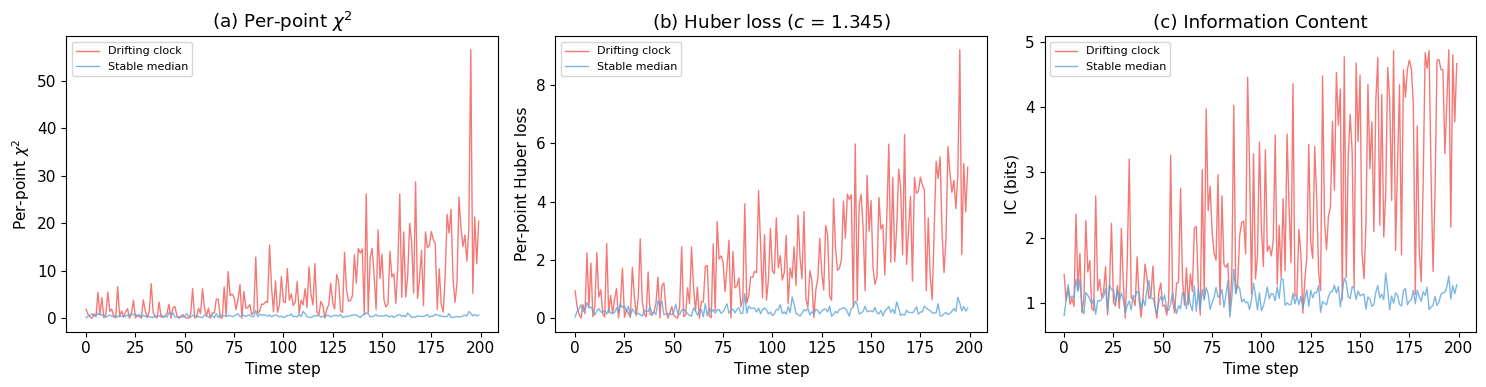

Drifting clock / stable median (last 50 steps):
    chi2: 25.2x
   Huber: 14.0x
      IC: 3.2x


In [9]:
from comparison import compute_chi2, compute_huber

# 20 clocks, T=200 steps. 19 stable, 1 drifting.
N_CMP = 20
T_CMP = 200
DRIFT = 0.02
rng_cmp = np.random.default_rng(2026)

vals = np.zeros((T_CMP, N_CMP))
sigs = np.ones((T_CMP, N_CMP))
for t_step in range(T_CMP):
    vals[t_step, 1:] = rng_cmp.normal(0, 1, N_CMP - 1)
    vals[t_step, 0] = rng_cmp.normal(0, 1) + DRIFT * t_step

# Compute per-step figures of merit (cross-sectional: all 20 clocks at each step)
chi2_all = np.array([compute_chi2(vals[t], sigs[t]) for t in range(T_CMP)])
huber_all = np.array([compute_huber(vals[t], sigs[t], c=1.345) for t in range(T_CMP)])
ic_all = np.array([compute_ic(vals[t], sigs[t]) for t in range(T_CMP)])

time = np.arange(T_CMP)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title, ylabel in [
    (axes[0], chi2_all, '(a) Per-point $\\chi^2$', 'Per-point $\\chi^2$'),
    (axes[1], huber_all, '(b) Huber loss ($c$ = 1.345)', 'Per-point Huber loss'),
    (axes[2], ic_all, '(c) Information Content', 'IC (bits)'),
]:
    ax.plot(time, data[:, 0], color='#F15854', linewidth=1, alpha=0.8, label='Drifting clock')
    ax.plot(time, np.median(data[:, 1:], axis=1), color='#5DA5DA', linewidth=1, alpha=0.8,
            label='Stable median')
    ax.set_xlabel('Time step')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Ratios over last 50 steps
print("Drifting clock / stable median (last 50 steps):")
for name, data in [('chi2', chi2_all), ('Huber', huber_all), ('IC', ic_all)]:
    d = np.mean(data[-50:, 0])
    s = np.mean(np.median(data[-50:, 1:], axis=1))
    print(f"  {name:>6}: {d/s:.1f}x")

IC does not replace $\chi^2$ or Huber loss — they optimise for different objectives (least squares vs bounded influence). IC's role is to separate **detection** (is this reading anomalous?) from **interpretation** (is the anomaly structured or unstructured?). The downstream classification step is what distinguishes this project's approach from established methods.

| Property | $\chi^2$ / residuals | Huber loss | Allan deviation | IC / AIPP |
|----------|---------------------|------------|-----------------|-----------|
| Scale behaviour | quadratic | linear beyond threshold | N/A (variance scaling) | logarithmic (via probability) |
| Dependence on $\sigma$ | explicit, quadratic | explicit | implicit (via noise model) | explicit, nonlinear |
| Additivity | yes (sum of squares) | yes | no (windowed statistic) | yes (information units) |
| Tail sensitivity | very high | bounded | not designed for outliers | distribution-dependent |
| Temporal structure | none | none | scaling only | none (pointwise) |

Allan deviation (not plotted) is structurally different — it characterises frequency stability as a function of averaging time, not pointwise anomaly scores. See logbook [Entry 005](../logbook/005_2026-04-01_positioning-ic-against-fom.md) for the full comparison.

## 10. What's next

WP1 has defined and calibrated IC as a single-clock, longitudinal observable. Its limitations are known: it is sensitive to systematic $\sigma$-misestimation, and alone it cannot distinguish random from structured deviations.

The question now is whether this per-clock observable — extended to a network context with causal ordering (Lamport timestamps) to structure cross-clock comparisons — can improve consensus. WP2 will simulate networks of clocks with realistic noise (hydrogen maser parameters from Panfilo & Arias 2019), inject structured and unstructured anomalies, and compare nine estimators including frequentist averaging, Huber M-estimation, Bayesian online changepoint detection, an interacting multiple model filter, and three ADMEC variants that use the IC-based classification.

Both positive and negative results will be published. The decision gates ([DG-2, DG-2b, DG-3](../index.md)) define explicit success criteria and failure conditions.

For the full technical record, see:
- [WP1 Summary](../logbook/wp1-summary.md) — what was defined, demonstrated, and not solved
- [Logbook entries 001–005](../logbook/) — chronological record with figures
- [Data archive](../data/) — all numerical output as `.npz` files
- [Project proposal](../docs/projektantrag.md) — objectives, work packages, and decision gates

## What happened next

This tutorial reflects WP1 as the work package closed: IC defined and calibrated, the per-reading 95th-percentile threshold set at **2.976 bit** (worst-case-σ regime, [logbook entry 006](../logbook/006_2026-05-04_per-reading-threshold-recalibration.md)).

WP2 then built the network simulation harness and applied that threshold to a 9-estimator × 8-scenario × 10-seed campaign. **DG-2 was not met** at the calibrated threshold (only the dense low-delay control S2 saw `admec_full` beat centralised baselines). See [`docs/wp2_tutorial.md`](../docs/wp2_tutorial.md) for the network walkthrough.

WP3 then ran a five-axis ablation sweep to characterise *why* DG-2 failed. Two of those findings are relevant to the WP1 design choices documented in this tutorial:

1. **The threshold sweep (entry 011) found that the WP1-calibrated 2.976 bit is suboptimal for consensus MSE in delayed scenarios.** Lower thresholds (1.5) halve `admec_full`'s S1 / S3 MSE. The WP1 calibration was correctly optimised for *null false-positive rate* — the right criterion for hypothesis-test interpretation — but the right value for downstream *consensus* depends on the deployment topology and signal regime. The two are different optimisation problems with different optima.

2. **The two-vs-three-way ablation (entry 010) found the structured/unstructured split is invisible to the WP2/WP3 consensus rule.** The classifier defined here emits a three-valued symbol; the consensus update rule reads only the binary STABLE / not-STABLE projection. The temporal-statistic gates (`δ_min_var`, `δ_min_acf`) are operating as designed but are not consumed downstream — a *syntactic gap* that requires an architectural redesign to close, not a tuning fix.

For the full WP3 sweep see [`docs/wp3_tutorial.md`](../docs/wp3_tutorial.md). For the manuscript synthesis (constraint discovery rather than tuning failure) see [`docs/manuscript.md`](../docs/manuscript.md).
